In [2]:
# === 設定（Secretsは直書きしない） ===
SHEET_NAME = 'バレースタッツ'   # スプレッドシート名
WORKSHEET_NAME = '生データ'      # タブ名
SHEET_ID = ''                    # 任意: URLの /d/ と /edit の間

# Colab の「シークレット」へ以下キー名で登録してください。
# - NOTION_TOKEN
# - PAGE_ID
# - IMGUR_CLIENT_ID
# - SHEET_ID（任意）
NOTION_TOKEN_KEY = 'NOTION_TOKEN'
PAGE_ID_KEY = 'PAGE_ID'
IMGUR_CLIENT_ID_KEY = 'IMGUR_CLIENT_ID'
SHEET_ID_KEY = 'SHEET_ID'



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ローカル秘密ファイルを読み込みました: .local_secrets.json
Google認証ファイルを使用: volleyball-stats-492014-ac04691fa39c.json
SHEET_IDを使用してスプレッドシートを開きます。
データ: 90件 / 2試合
  20260322 vs ネオ: 21-25 (負)
  20260329 vs レジン: 19-25 (負)

20260322 vs ネオ

レセプション (計22本)
  A: 4本 18.2% 
  B: 3本 13.6% 
  C: 12本 54.5% 
  D: 3本 13.6% （失点）

サーブ (計2本)
  得点: 0
  ミス: 2
    - アウト: 1
    - その他: 1

スパイク (計21本)
  得点: 11
  ミス: 10
    - アウト: 4
    - シャット: 2
    - ネット: 2
    - ブロック: 1
    - その他: 1

ブロック (計7本)
  得点: 3
  ミス: 4
    - タッチアウト: 2
    - アウト: 2

ディグ (計5本)
  得点: 0
  ミス: 5
    - その他: 4
    - お見合い: 1

20260329 vs レジン

レセプション (計20本)
  A: 4本 20.0% 
  B: 0本 0.0% 
  C: 14本 70.0% 
  D: 2本 10.0% （失点）

サーブ (計3本)
  得点: 1
  ミス: 2
    - ネット: 1
    - その他: 1

スパイク (計12本)
  得点: 7
  ミス: 5
    - シャット: 3
    - アウト: 1
    - ネット: 1

プッシュ (計1本)
  得点: 1
  ミス: 0

ブロック (計10本)
  得点: 2
  ミス: 8
    - ポジション: 3
    - タッチアウト: 2
    - 吸い込み: 1
    - タッチイン: 1
    - その他: 1

ディグ (計6本)
  得点: 0
  ミス: 6
    - その他: 5
    - オーバーネット: 1

2段トス (計1本)
  得点: 0
  ミス: 1
    - その他:

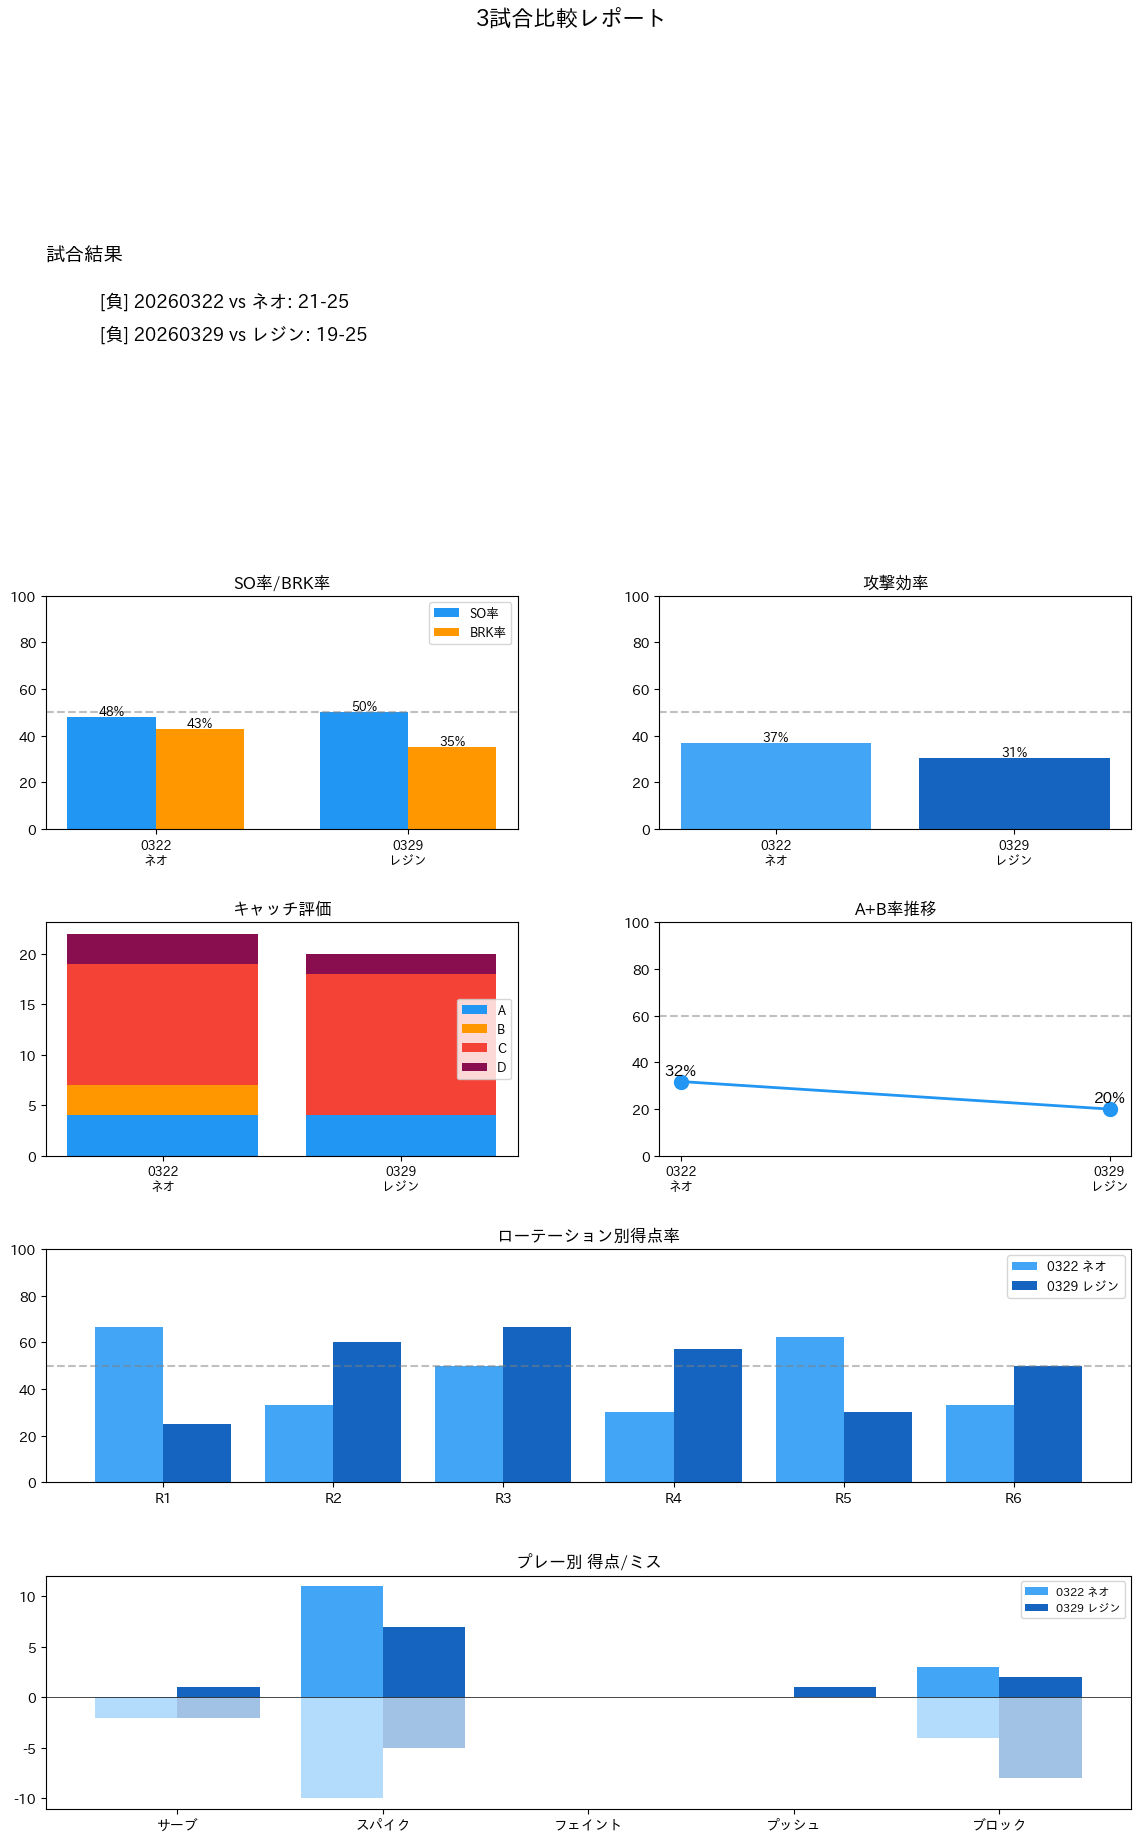


Notion更新完了！
https://www.notion.so/331feaabd15e80b092a8f392c9157be3


In [ ]:
# === 全自動実行（このセルだけ実行すればOK） ===

!pip install notion-client japanize-matplotlib gspread google-auth -q

import os
import json
from pathlib import Path

try:
    from google.colab import auth, userdata
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

# ローカル実行用の秘密ファイル（このパスは .gitignore 対象にする）
LOCAL_SECRET_FILE = globals().get('LOCAL_SECRET_FILE', 'analysis/.local_secrets.json')


def load_local_secrets(file_path):
    # 実行ディレクトリ差異に対応するため複数候補を試す
    candidates = [
        Path(file_path),
        Path('.local_secrets.json'),
        Path('analysis/.local_secrets.json'),
    ]

    seen = set()
    for p in candidates:
        rp = str(p.resolve()) if p.exists() else str(p)
        if rp in seen:
            continue
        seen.add(rp)

        if not p.exists():
            continue
        try:
            data = json.loads(p.read_text(encoding='utf-8'))
            if isinstance(data, dict):
                print(f'ローカル秘密ファイルを読み込みました: {p}')
                return data
        except Exception:
            pass

    return {}


LOCAL_SECRETS = load_local_secrets(LOCAL_SECRET_FILE)


def get_secret(key_name):
    # ColabではSecrets、ローカルでは「環境変数 → 秘密ファイル」の順で取得
    if IN_COLAB:
        try:
            value = userdata.get(key_name)
            if value is None:
                value = ''
            return str(value).strip()
        except Exception:
            return ''

    env_value = str(os.getenv(key_name, '')).strip()
    if env_value:
        return env_value

    file_value = LOCAL_SECRETS.get(key_name, '')
    return str(file_value).strip()


if IN_COLAB:
    auth.authenticate_user()

# セル0未実行でも動くように既定キー名を補完
NOTION_TOKEN_KEY = globals().get('NOTION_TOKEN_KEY', 'NOTION_TOKEN')
PAGE_ID_KEY = globals().get('PAGE_ID_KEY', 'PAGE_ID')
IMGUR_CLIENT_ID_KEY = globals().get('IMGUR_CLIENT_ID_KEY', 'IMGUR_CLIENT_ID')
SHEET_ID_KEY = globals().get('SHEET_ID_KEY', 'SHEET_ID')
WORKSHEET_NAME = globals().get('WORKSHEET_NAME', '生データ')

NOTION_TOKEN = get_secret(NOTION_TOKEN_KEY)
PAGE_ID = get_secret(PAGE_ID_KEY)
IMGUR_CLIENT_ID = get_secret(IMGUR_CLIENT_ID_KEY)
SHEET_ID = globals().get('SHEET_ID', '') or get_secret(SHEET_ID_KEY)

missing = []
if not NOTION_TOKEN:
    missing.append(NOTION_TOKEN_KEY)
if not PAGE_ID:
    missing.append(PAGE_ID_KEY)
if not IMGUR_CLIENT_ID:
    missing.append(IMGUR_CLIENT_ID_KEY)

if missing and IN_COLAB:
    raise ValueError(
        'Colabシークレットが不足しています: ' + ', '.join(missing) +
        '。左パネルのSecretsで登録してから再実行してください。'
    )

# ローカル実行では、未設定分を対話入力で補完できるようにする
if missing and not IN_COLAB:
    from getpass import getpass

    print('不足している値を入力してください（入力内容は表示されません）。')
    print(f'ヒント: {LOCAL_SECRET_FILE} に保存しておくと次回以降の入力は不要です。')

    if not NOTION_TOKEN:
        NOTION_TOKEN = getpass(f'{NOTION_TOKEN_KEY}: ').strip()
    if not PAGE_ID:
        PAGE_ID = getpass(f'{PAGE_ID_KEY}: ').strip()
    if not IMGUR_CLIENT_ID:
        IMGUR_CLIENT_ID = getpass(f'{IMGUR_CLIENT_ID_KEY}: ').strip()

    missing = []
    if not NOTION_TOKEN:
        missing.append(NOTION_TOKEN_KEY)
    if not PAGE_ID:
        missing.append(PAGE_ID_KEY)
    if not IMGUR_CLIENT_ID:
        missing.append(IMGUR_CLIENT_ID_KEY)

    if missing:
        raise ValueError(
            '入力後も不足しています: ' + ', '.join(missing) +
            '。値を確認して再実行してください。'
        )

import gspread
if IN_COLAB:
    from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import japanize_matplotlib
from notion_client import Client
import requests, base64
import numpy as np

plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

# === データ読み込み ===
if IN_COLAB:
    creds, _ = default()
    gc = gspread.authorize(creds)
else:
    # ローカル実行時は service_account ファイルを複数候補から探索
    service_account_file = str(LOCAL_SECRETS.get('GOOGLE_SERVICE_ACCOUNT_FILE', '')).strip()
    candidates = []
    if service_account_file:
        p = Path(service_account_file)
        candidates.append(p)
        # 実行ディレクトリ差異で analysis/ が二重になるケースを吸収
        candidates.append(Path(p.name))
    candidates.extend([
        Path('service_account.json'),
        Path('analysis/service_account.json'),
        Path('volleyball-stats-492014-ac04691fa39c.json'),
        Path('analysis/volleyball-stats-492014-ac04691fa39c.json'),
    ])

    picked = None
    for p in candidates:
        if p.exists():
            picked = str(p)
            break

    try:
        if picked:
            print(f'Google認証ファイルを使用: {picked}')
            gc = gspread.service_account(filename=picked)
        else:
            gc = gspread.service_account()
    except Exception as e:
        raise RuntimeError(
            'Google Sheets認証に失敗しました。service_account.json を配置するか、'
            'analysis/.local_secrets.json に GOOGLE_SERVICE_ACCOUNT_FILE を設定してください。'
        ) from e

# SHEET_ID があればID優先で開く（名前ぶれに強い）
if SHEET_ID:
    print('SHEET_IDを使用してスプレッドシートを開きます。')
    sh = gc.open_by_key(SHEET_ID)
else:
    try:
        sh = gc.open(SHEET_NAME)
    except Exception as e:
        raise RuntimeError(
            f'スプレッドシート名 "{SHEET_NAME}" で見つかりません。'
            'analysis/.local_secrets.json に SHEET_ID を追加してください。'
        ) from e

df = pd.DataFrame(sh.worksheet(WORKSHEET_NAME).get_all_records())

for col in ['score_us','score_them','set','rotation']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
str_cols = ['date','opponent','point_team','serve_team','team','player',
            'play_type','result','result_detail','receive_grade','receiver',
            'attack_type','blocker_count','zone_from','zone_to','note']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
df['date'] = df['date'].astype(str)
df['match_key'] = df['date'] + '_' + df['opponent']

matches = df.groupby('match_key').first()[['date','opponent']].reset_index()
matches = matches.sort_values('date', ascending=False)
recent_3 = matches.head(3)['match_key'].tolist()

print(f'データ: {len(df)}件 / {len(matches)}試合')

# === 分析 ===
def analyze_match(mdf):
    last = mdf.iloc[-1]
    info = {
        'date':str(last['date']),'opponent':str(last['opponent']),
        'score_us':int(last['score_us']),'score_them':int(last['score_them']),
        'sets':int(mdf['set'].max()),'rallies':len(mdf),
    }
    info['result'] = '勝' if info['score_us']>info['score_them'] else '負' if info['score_us']<info['score_them'] else '分'
    osv=mdf[mdf['serve_team']!='自チーム'];info['so_total']=len(osv)
    info['so_won']=len(osv[osv['point_team']=='自チーム']) if len(osv)>0 else 0
    info['so_rate']=info['so_won']/info['so_total']*100 if info['so_total']>0 else 0
    usv=mdf[mdf['serve_team']=='自チーム'];info['brk_total']=len(usv)
    info['brk_won']=len(usv[usv['point_team']=='自チーム']) if len(usv)>0 else 0
    info['brk_rate']=info['brk_won']/info['brk_total']*100 if info['brk_total']>0 else 0
    recv=mdf[mdf['receive_grade'].isin(['A','B','C','D'])];info['recv_total']=len(recv)
    for g in ['A','B','C','D']:info[f'recv_{g}']=len(recv[recv['receive_grade']==g])
    info['recv_ab_rate']=(info['recv_A']+info['recv_B'])/info['recv_total']*100 if info['recv_total']>0 else 0
    info['rot']={}
    for r in range(1,7):
        rd=mdf[mdf['rotation']==r]
        if len(rd)>0:
            w=int((rd['point_team']=='自チーム').sum());l=int((rd['point_team']!='自チーム').sum())
            info['rot'][r]={'won':w,'lost':l,'rate':w/(w+l)*100 if(w+l)>0 else 0}
        else:info['rot'][r]={'won':0,'lost':0,'rate':0}
    us=mdf[mdf['team']=='自チーム'];us_pt=us[us['result']=='得点'];us_ms=us[us['result']=='ミス']
    info['us_points']=len(us_pt);info['us_miss']=len(us_ms)
    t=info['us_points']+info['us_miss'];info['us_eff']=info['us_points']/t*100 if t>0 else 0
    info['play_points']={};info['play_miss']={}
    for p in ['サーブ','スパイク','フェイント','プッシュ','ブロック']:
        info['play_points'][p]=len(us_pt[us_pt['play_type']==p])
        info['play_miss'][p]=len(us_ms[us_ms['play_type']==p])
    return info

results=[analyze_match(df[df['match_key']==mk].copy()) for mk in recent_3][::-1]
n=len(results);short_labels=[f"{r['date'][-4:]}\n{r['opponent']}" for r in results]
for r in results:print(f"  {r['date']} vs {r['opponent']}: {r['score_us']}-{r['score_them']} ({r['result']})")

# プレー別詳細分析

def analyze_play_detail(mdf):
    """1試合のプレー別詳細を分析"""
    us = mdf[mdf['team'] == '自チーム']
    detail = {}

    # --- レセプション ---
    recv = mdf[mdf['receive_grade'].isin(['A','B','C','D'])]
    recv_total = len(recv)
    recv_detail = {}
    for g in ['A','B','C','D']:
        c = len(recv[recv['receive_grade'] == g])
        recv_detail[g] = {
            'count': c,
            'pct': c / recv_total * 100 if recv_total > 0 else 0
        }
    recv_detail['total'] = recv_total
    detail['レセプション'] = recv_detail

    # --- プレー別（サーブ/スパイク/ブロック/ディグ等） ---
    for play in ['サーブ','スパイク','フェイント','プッシュ','ブロック','ディグ','2段トス','フリーボール']:
        play_data = us[us['play_type'] == play]
        if len(play_data) == 0:
            continue

        pts = play_data[play_data['result'] == '得点']
        miss = play_data[play_data['result'] == 'ミス']

        # ミスの内訳
        miss_detail = {}
        if len(miss) > 0:
            for d in miss['result_detail'].unique():
                if d and str(d).strip():
                    miss_detail[str(d)] = len(miss[miss['result_detail'] == d])
            # result_detail が空のミス
            empty_miss = len(miss[miss['result_detail'].isin(['','nan','None'])])
            if empty_miss > 0:
                miss_detail['入力なし'] = miss_detail.get('入力なし', 0) + empty_miss

        detail[play] = {
            'points': len(pts),
            'miss': len(miss),
            'total': len(play_data),
            'miss_detail': miss_detail,
        }

    return detail

# 3試合分の詳細分析
details = []
for mk in recent_3:
    mdf = df[df['match_key'] == mk].copy()
    d = analyze_play_detail(mdf)
    last = mdf.iloc[-1]
    d['_date'] = str(last['date'])
    d['_opponent'] = str(last['opponent'])
    details.append(d)

details = details[::-1]  # 古い順

# 表示
for d in details:
    print(f"\n{'='*50}")
    print(f"{d['_date']} vs {d['_opponent']}")
    print(f"{'='*50}")

    # レセプション
    recv = d['レセプション']
    print(f"\nレセプション (計{recv['total']}本)")
    for g in ['A','B','C','D']:
        r = recv[g]
        label = '（失点）' if g == 'D' else ''
        print(f"  {g}: {r['count']}本 {r['pct']:.1f}% {label}")

    # 各プレー
    for play in ['サーブ','スパイク','フェイント','プッシュ','ブロック','ディグ','2段トス','フリーボール']:
        if play not in d or play == 'レセプション':
            continue
        p = d[play]
        if p['total'] == 0:
            continue
        print(f"\n{play} (計{p['total']}本)")
        print(f"  得点: {p['points']}")
        print(f"  ミス: {p['miss']}")
        if p['miss_detail']:
            for k, v in sorted(p['miss_detail'].items(), key=lambda x: -x[1]):
                print(f"    - {k}: {v}")

# === グラフ生成 ===
colors=['#90CAF9','#42A5F5','#1565C0'][-n:]
x=np.arange(n)
fig=plt.figure(figsize=(14,20))
gs=gridspec.GridSpec(5,2,hspace=0.4,wspace=0.3)

ax=fig.add_subplot(gs[0,:]);ax.axis('off')
s=''
for r in results:s+=f"[{r['result']}] {r['date']} vs {r['opponent']}: {r['score_us']}-{r['score_them']}\n"
ax.text(0.05,0.9,s,transform=ax.transAxes,fontsize=13,verticalalignment='top',linespacing=2)
ax.set_title('試合結果',fontsize=14,fontweight='bold',loc='left')

ax=fig.add_subplot(gs[1,0]);w=0.35
bars1=ax.bar(x-w/2,[r['so_rate'] for r in results],w,label='SO率',color='#2196F3')
bars2=ax.bar(x+w/2,[r['brk_rate'] for r in results],w,label='BRK率',color='#FF9800')
ax.set_xticks(x);ax.set_xticklabels(short_labels,fontsize=9);ax.set_ylim(0,100)
ax.set_title('SO率/BRK率');ax.legend(fontsize=9);ax.axhline(y=50,color='gray',linestyle='--',alpha=0.5)
for b in bars1:ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{b.get_height():.0f}%',ha='center',fontsize=9)
for b in bars2:ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{b.get_height():.0f}%',ha='center',fontsize=9)

ax=fig.add_subplot(gs[1,1])
bars=ax.bar(x,[r['us_eff'] for r in results],color=colors)
ax.set_xticks(x);ax.set_xticklabels(short_labels,fontsize=9);ax.set_ylim(0,100)
ax.set_title('攻撃効率');ax.axhline(y=50,color='gray',linestyle='--',alpha=0.5)
for b in bars:ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{b.get_height():.0f}%',ha='center',fontsize=9)

ax=fig.add_subplot(gs[2,0])
gc2={'A':'#2196F3','B':'#FF9800','C':'#f44336','D':'#880E4F'};bt=np.zeros(n)
for g in ['A','B','C','D']:
    v=[r[f'recv_{g}'] for r in results];ax.bar(x,v,bottom=bt,label=g,color=gc2[g]);bt+=np.array(v,dtype=float)
ax.set_xticks(x);ax.set_xticklabels(short_labels,fontsize=9);ax.set_title('キャッチ評価');ax.legend(fontsize=9)

ax=fig.add_subplot(gs[2,1])
ab=[r['recv_ab_rate'] for r in results];ax.plot(x,ab,'o-',color='#2196F3',markersize=10,linewidth=2)
ax.set_xticks(x);ax.set_xticklabels(short_labels,fontsize=9);ax.set_ylim(0,100)
ax.set_title('A+B率推移');ax.axhline(y=60,color='gray',linestyle='--',alpha=0.5)
for i,v in enumerate(ab):ax.text(i,v+3,f'{v:.0f}%',ha='center',fontsize=11,fontweight='bold')

ax=fig.add_subplot(gs[3,:]);bw=0.8/n
for i,r in enumerate(results):
    ax.bar(np.arange(6)+(i-n/2+0.5)*bw,[r['rot'][j]['rate'] for j in range(1,7)],bw,label=short_labels[i].replace('\n',' '),color=colors[i])
ax.set_xticks(np.arange(6));ax.set_xticklabels([f'R{i}' for i in range(1,7)]);ax.set_ylim(0,100)
ax.set_title('ローテーション別得点率');ax.legend(fontsize=9);ax.axhline(y=50,color='gray',linestyle='--',alpha=0.5)

ax=fig.add_subplot(gs[4,:]);plays=['サーブ','スパイク','フェイント','プッシュ','ブロック'];bw=0.8/n
for i,r in enumerate(results):
    o=(i-n/2+0.5)*bw
    ax.bar(np.arange(5)+o,[r['play_points'].get(p,0) for p in plays],bw,color=colors[i],label=short_labels[i].replace('\n',' '))
    ax.bar(np.arange(5)+o,[-r['play_miss'].get(p,0) for p in plays],bw,color=colors[i],alpha=0.4)
ax.set_xticks(np.arange(5));ax.set_xticklabels(plays);ax.set_title('プレー別 得点/ミス');ax.axhline(y=0,color='black',linewidth=0.5);ax.legend(fontsize=8)

plt.suptitle('3試合比較レポート',fontsize=16,fontweight='bold',y=1.01)
report_path = '/content/report.png' if IN_COLAB else 'report.png'
plt.savefig(report_path,dpi=150,bbox_inches='tight');plt.show()

# === Notion書き込み ===
notion = Client(auth=NOTION_TOKEN)
P = PAGE_ID


def upload_image(fp):
    with open(fp, 'rb') as f:
        b = base64.b64encode(f.read()).decode()

    res = requests.post(
        'https://api.imgur.com/3/image',
        headers={'Authorization': f'Client-ID {IMGUR_CLIENT_ID}'},
        data={'image': b},
        timeout=30,
    )
    res.raise_for_status()
    payload = res.json()
    if 'data' not in payload or 'link' not in payload['data']:
        raise RuntimeError(f'Imgurアップロード失敗: {payload}')
    return payload['data']['link']


def add_heading(pid, t, l=2):
    notion.blocks.children.append(block_id=pid, children=[{'type': f'heading_{l}', f'heading_{l}': {'rich_text': [{'text': {'content': t}}]}}])


def add_text(pid, t):
    notion.blocks.children.append(block_id=pid, children=[{'type': 'paragraph', 'paragraph': {'rich_text': [{'text': {'content': t}}]}}])


def add_image(pid, u):
    notion.blocks.children.append(block_id=pid, children=[{'type': 'image', 'image': {'type': 'external', 'external': {'url': u}}}])


def add_divider(pid):
    notion.blocks.children.append(block_id=pid, children=[{'type': 'divider', 'divider': {}}])


def add_table(pid, h, rows):
    w = len(h)
    trs = [{'type': 'table_row', 'table_row': {'cells': [[{'type': 'text', 'text': {'content': str(v)}}] for v in h]}}]
    for row in rows:
        trs.append({'type': 'table_row', 'table_row': {'cells': [[{'type': 'text', 'text': {'content': str(v)}}] for v in row]}})
    notion.blocks.children.append(block_id=pid, children=[{'type': 'table', 'table': {'table_width': w, 'has_column_header': True, 'has_row_header': False, 'children': trs}}])

# クリア
for b in notion.blocks.children.list(block_id=P)['results']:
    try:notion.blocks.delete(block_id=b['id'])
    except:pass

# 書き込み
add_heading(P,'3試合比較レポート',1)
add_text(P,f"最終更新: {results[-1]['date']} vs {results[-1]['opponent']} | 全{len(df)}ラリー")
add_divider(P)

add_heading(P,'試合結果')
add_table(P,['日付','相手','スコア','結果'],
    [[r['date'],r['opponent'],f"{r['score_us']}-{r['score_them']}",r['result']] for r in results])
add_divider(P)

add_heading(P,'サイドアウト率 / ブレイク率')
add_table(P,['日付','相手','SO率','BRK率','攻撃効率'],
    [[r['date'],r['opponent'],
      f"{r['so_rate']:.1f}% ({r['so_won']}/{r['so_total']})",
      f"{r['brk_rate']:.1f}% ({r['brk_won']}/{r['brk_total']})",
      f"{r['us_eff']:.1f}%"] for r in results])
add_divider(P)

add_heading(P,'サーブキャッチ')
add_table(P,['日付','相手','A','B','C','D','A+B率'],
    [[r['date'],r['opponent'],r['recv_A'],r['recv_B'],r['recv_C'],r['recv_D'],
      f"{r['recv_ab_rate']:.1f}%"] for r in results])
add_divider(P)

add_heading(P,'ローテーション別得点率')
rh=['日付','相手']+[f'R{i}' for i in range(1,7)]
rr=[]
for r in results:
    row=[r['date'],r['opponent']]
    for i in range(1,7):
        rd=r['rot'][i];t=rd['won']+rd['lost']
        row.append(f"{rd['rate']:.0f}% ({rd['won']}/{t})")
    rr.append(row)
add_table(P,rh,rr)
add_divider(P)

add_heading(P,'プレー別 得点/ミス')
plays=['サーブ','スパイク','フェイント','プッシュ','ブロック']
add_table(P,['日付','相手']+plays,
    [[r['date'],r['opponent']]+[f"{r['play_points'].get(p,0)}得/{r['play_miss'].get(p,0)}失" for p in plays] for r in results])
add_divider(P)

add_heading(P,'比較グラフ')
add_image(P,upload_image(report_path))



# プレー別詳細をNotionに書き込み

add_divider(P)
add_heading(P, 'プレー別詳細分析')

for d in details:
    add_heading(P, f"{d['_date']} vs {d['_opponent']}", 3)

    # レセプション
    recv = d['レセプション']
    if recv['total'] > 0:
        add_text(P, f"レセプション（計{recv['total']}本）")
        recv_rows = []
        for g in ['A','B','C','D']:
            r = recv[g]
            label = '（失点）' if g == 'D' else ''
            recv_rows.append([g, f"{r['count']}本", f"{r['pct']:.1f}%", label])
        add_table(P, ['評価','本数','割合','備考'], recv_rows)

    # 各プレー
    for play in ['サーブ','スパイク','フェイント','プッシュ','ブロック','ディグ']:
        if play not in d:
            continue
        p = d[play]
        if p['total'] == 0:
            continue

        text = f"{play}：得点{p['points']} / ミス{p['miss']}"
        if p['miss_detail']:
            details_text = '、'.join([f"{k}{v}" for k, v in sorted(p['miss_detail'].items(), key=lambda x: -x[1])])
            text += f"（{details_text}）"
        add_text(P, text)

    add_divider(P)

print()
print('================================')
print('Notion更新完了！')
print(f'https://www.notion.so/{PAGE_ID}')
print('================================')